## Introduction

Exploratory Data Analysis (EDA) is an important step in data science that helps us understand the structure, patterns, trends, and relationships present in a dataset. In this project, EDA is performed on the Titanic passenger dataset using Python. Statistical summaries and visualizations are used to analyze passenger characteristics and identify factors associated with survival.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# Dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (891, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


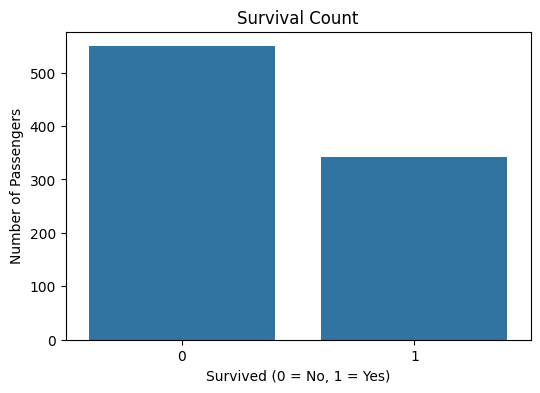

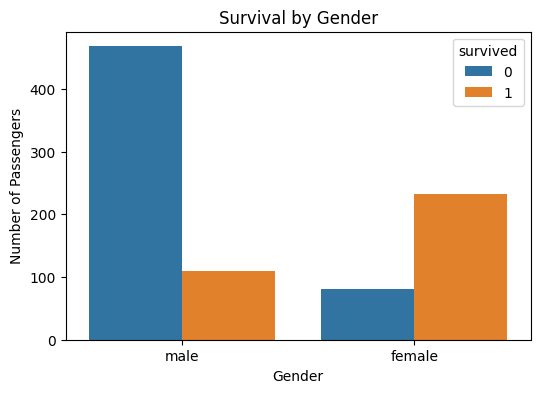

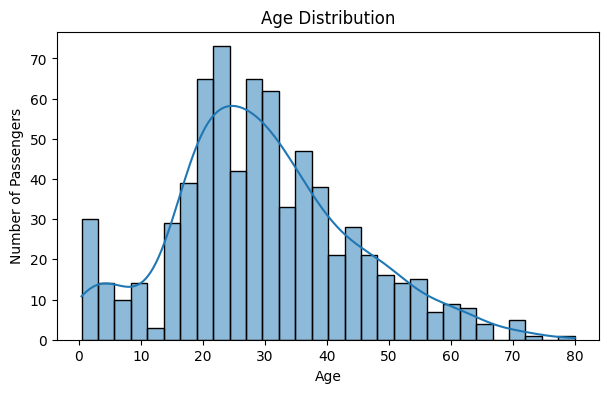

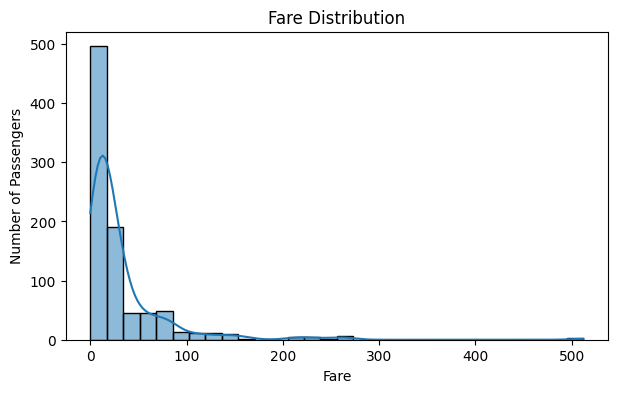

In [4]:
# EDA Visualizations

# 1. Survival count
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# 2. Survival by gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()


# 3. Age distribution
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


# 4. Fare distribution
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

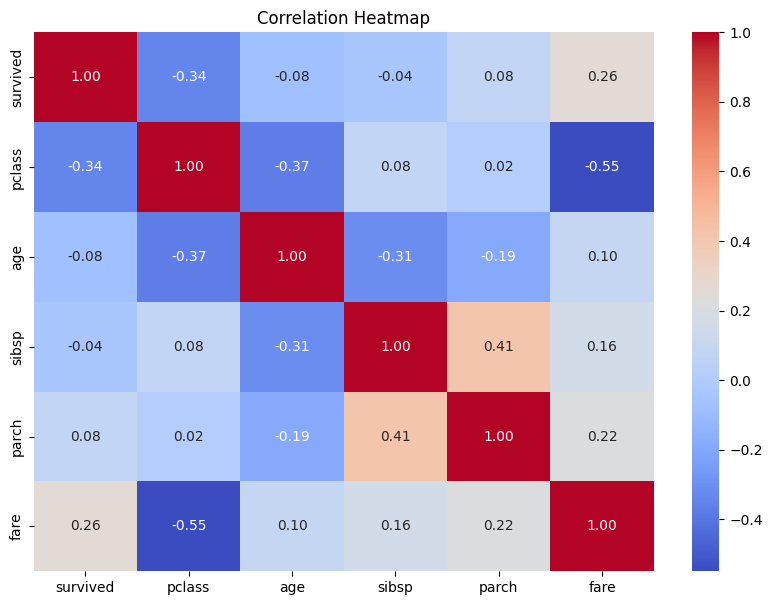

In [5]:
# Correlation Analysis

# Select numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Calculate correlation
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [6]:
# Key Influencing Factors

# Survival rate by gender
print("Survival Rate by Gender:")
print(df.groupby("sex")["survived"].mean().round(2))

# Survival rate by passenger class
print("\nSurvival Rate by Passenger Class:")
print(df.groupby("pclass")["survived"].mean().round(2))

# Survival rate by embarkation town
print("\nSurvival Rate by Embarkation Town:")
print(df.groupby("embark_town")["survived"].mean().round(2))

Survival Rate by Gender:
sex
female    0.74
male      0.19
Name: survived, dtype: float64

Survival Rate by Passenger Class:
pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64

Survival Rate by Embarkation Town:
embark_town
Cherbourg      0.55
Queenstown     0.39
Southampton    0.34
Name: survived, dtype: float64


In [7]:
# Final EDA Insights

print("""
EDA INSIGHTS
------------
1. The dataset contains 891 passengers and 15 variables.
2. The average passenger age is approximately 29.7 years.
3. Survival differs between male and female passengers.
4. Passenger class is associated with survival outcomes.
5. Passenger fare shows variation across passengers and classes.
6. The correlation analysis helps identify relationships between numerical variables.
7. Missing values are present mainly in age and deck-related columns.
""")


EDA INSIGHTS
------------
1. The dataset contains 891 passengers and 15 variables.
2. The average passenger age is approximately 29.7 years.
3. Survival differs between male and female passengers.
4. Passenger class is associated with survival outcomes.
5. Passenger fare shows variation across passengers and classes.
6. The correlation analysis helps identify relationships between numerical variables.
7. Missing values are present mainly in age and deck-related columns.



# Exploratory Data Analysis (EDA) Project

## Title
### Exploratory Data Analysis of Titanic Passenger Dataset

## 1. Objective
The objective of this project is to analyze a dataset using statistical methods and visualizations to identify patterns, trends, relationships, and important factors influencing passenger survival.

## 2. Dataset
The Titanic dataset contains information about 891 passengers and 15 variables, including:

- Passenger survival
- Passenger class
- Gender
- Age
- Number of siblings/spouses
- Number of parents/children
- Fare
- Port of embarkation
- Passenger class and other related information

## 3. Tools and Technologies
- Python
- Google Colab
- Pandas
- Matplotlib
- Seaborn

## 4. Methodology
The following steps were performed:

1. Loaded the Titanic dataset.
2. Examined the structure and dimensions of the dataset.
3. Generated statistical summaries.
4. Checked the dataset for missing values.
5. Created visualizations to understand the data.
6. Analyzed correlations between numerical variables.
7. Identified important factors related to passenger survival.
8. Summarized the major findings.

## 5. Exploratory Data Analysis

### Dataset Overview
The dataset contains 891 rows and 15 columns.

The average passenger age is approximately 29.7 years.

### Statistical Analysis
Descriptive statistics such as mean, standard deviation, minimum, maximum, and quartiles were calculated for numerical variables.

### Visualizations
The following visualizations were created:

- Survival Count
- Survival by Gender
- Age Distribution
- Fare Distribution
- Correlation Heatmap

## 6. Key Findings

- Passenger survival varied between males and females.
- Passenger class showed a relationship with survival.
- Age was distributed across a wide range, with an average age of approximately 29.7 years.
- Fare values varied considerably among passengers.
- The correlation heatmap helped identify relationships between numerical variables.
- Missing values were present in some columns, particularly age and deck-related information.

## 7. Conclusion
This Exploratory Data Analysis provided insights into the Titanic passenger dataset using statistical summaries and data visualizations. The analysis identified important patterns and relationships among passenger characteristics and survival outcomes. The project demonstrates how EDA can be used to understand datasets and discover useful insights before applying machine-learning models.

## 8. Outcome
The project helped develop practical skills in data exploration, statistical analysis, visualization, correlation analysis, and interpretation of real-world datasets.